In [ ]:
#normal balancing just do resample same datapoints again and again so it overlaps the point and increase the count but there is no variance
# but smote connects 2 nearest point to each other by oversampling middle points by its own creating a variance as well as increasing datapoint no overlap.

from sklearn.datasets import make_classification # used for making datasets synthetic


In [ ]:
#make_classification use to create datasets with imbalacing as per choice in it with choice of features and imbalace ratio
make_classification(n_samples=1000, n_redundant=0, n_features=2, n_clusters_per_class=1, weights=[0.90],random_state=12)
#n_cluster is the groups under a class if you want to create. and n_redundant is the repetition of the features but we are only including to so we make it 0.
# random_state = “locks randomness so results stay the same every run”
#make_classification() creates synthetic values, meaning fake data generated by an algorithm (not real-world data).
#These values come from a normal distribution, so most numbers are near 0 and fewer are large.
#That’s why you see decimals like -1.07, 0.76, etc., instead of fixed numbers like 2 or 5.

#answer column is feature 1 and column 2 is feature two.

(array([[-0.76289759, -0.70680807],
        [-1.07543571, -1.0511621 ],
        [-0.61011459, -0.90980157],
        ...,
        [-1.32643852, -1.815178  ],
        [-0.83348573, -0.5146474 ],
        [-0.30287558, -0.57597532]]),
 array([0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 

In [ ]:
#above first answer is independent answer and next answer is dependent answer 
# so here we seperate them in variable.
x,y=make_classification(n_samples=1000, n_redundant=0, n_features=2, n_clusters_per_class=1, weights=[0.90],random_state=12)



In [6]:

import pandas as pd
df1=pd.DataFrame(x,columns=['Feature1','Feature2'])
df2=pd.DataFrame(y,columns=['target']) 
final_df=pd.concat([df1,df2],axis=1) 

In [7]:
final_df.head()

,Feature1,Feature2,target
0,-0.762898,-0.706808,0
1,-1.075436,-1.051162,0
2,-0.610115,-0.909802,0
3,-2.023284,-0.428945,1
4,-0.812921,-1.316206,0


In [11]:
final_df["target"].value_counts()

target
0    900
1    100
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt

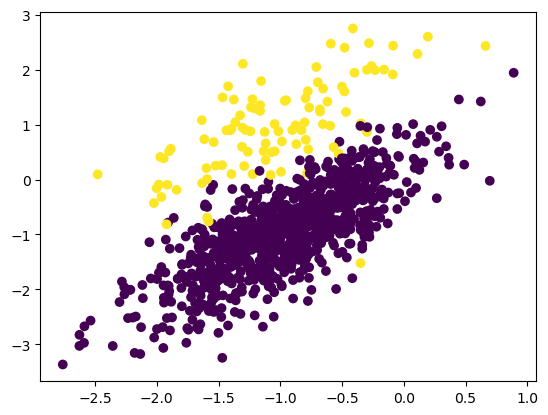

In [ ]:
plt.scatter(final_df["Feature1"],final_df["Feature2"],c=final_df["target"]) # c is with respect to target
# the answer is showing an imbalance data set .

In [14]:
from imblearn.over_sampling import SMOTE
# now using smote we cam over sample any minority by not involving overlapping in poinys but generating fake points between two nearest points which also
# increases the variance to make it more realistic data.

In [18]:
oversampling=SMOTE()
x,y=oversampling.fit_resample(final_df[['Feature1','Feature2']],final_df['target'])

In [20]:
x.shape

(1800, 2)

In [21]:
y.shape

(1800,)

In [25]:
#total zero counts
len(y[y==0])

900

In [26]:
len(y[y==1])

900

In [32]:
df1=pd.DataFrame(x,columns=['Feature1','Feature2'])
df2=pd.DataFrame(y,columns=['target'])
oversampled_df=pd.concat([df1,df2],axis=1)

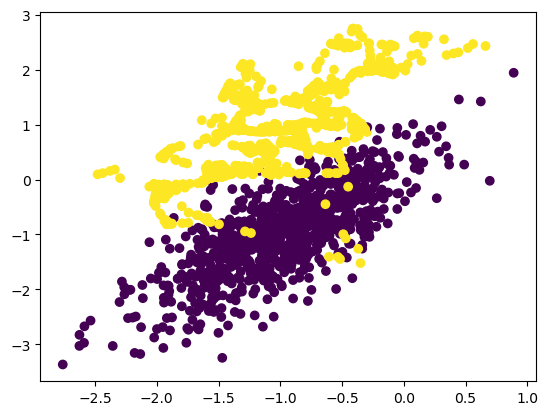

In [33]:
plt.scatter(oversampled_df['Feature1'],oversampled_df['Feature2'],c=oversampled_df['target'])

In [34]:
# so you can see that the datapoints in yellow are connected wuith each other with mulktiple fake points